<a href="https://colab.research.google.com/github/Hefot-Ahmed/Hefot-s-Python-Projects/blob/main/NVIDIA_6G_Developer_Program_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
try:
    import sionna.rt
except ImportError as e:
    import os
    os.system("pip install sionna-rt")
    import sionna.rt # Re-import after installation

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

no_preview = True

from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies

In [8]:
scene = load_scene(sionna.rt.scene.munich)

In [9]:
if not no_preview:
    scene.preview();

In [10]:
if not no_preview:
    scene.render(camera="preview", num_samples=512);

In [11]:
if not no_preview:
    scene.render_to_file(camera="preview",
                         filename="scene.png",
                         resolution=[650,500]);

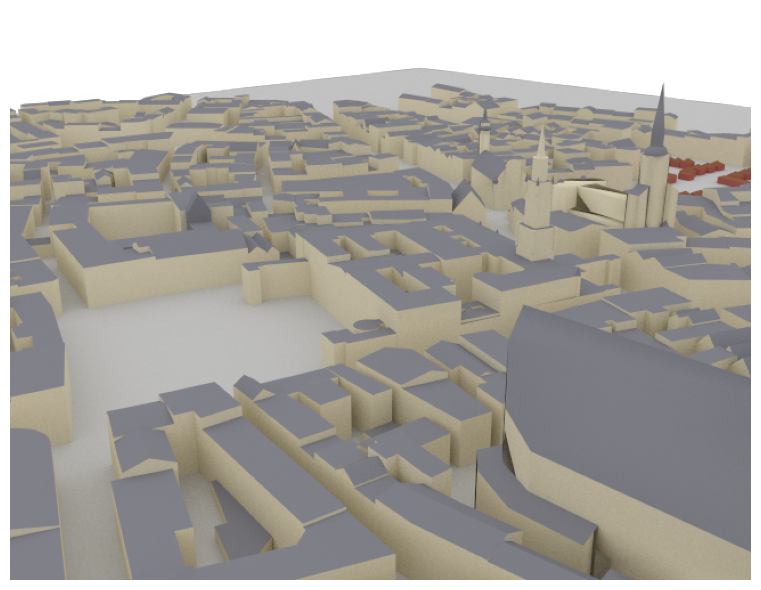

In [12]:
my_cam = Camera(position=[-250,250,150], look_at=[-15,30,28])

scene.render(camera=my_cam, resolution=[650, 500], num_samples=512);

In [13]:
scene = load_scene(sionna.rt.scene.simple_street_canyon, merge_shapes=False)
scene.objects

{'building_1': <sionna.rt.scene_object.SceneObject at 0x7b566007bec0>,
 'building_6': <sionna.rt.scene_object.SceneObject at 0x7b566007c2c0>,
 'building_5': <sionna.rt.scene_object.SceneObject at 0x7b566007c380>,
 'building_4': <sionna.rt.scene_object.SceneObject at 0x7b566007c4a0>,
 'building_3': <sionna.rt.scene_object.SceneObject at 0x7b566007c5c0>,
 'building_2': <sionna.rt.scene_object.SceneObject at 0x7b566007c710>,
 'floor': <sionna.rt.scene_object.SceneObject at 0x7b566007c890>}

In [14]:
floor = scene.get("floor")

In [15]:
print("Position (x,y,z) [m]: ", floor.position)
print("Orientation (alpha, beta, gamma) [rad]: ", floor.orientation)
print("Scaling: ", floor.scaling)

Position (x,y,z) [m]:  [[-0.769669, 0.238537, -0.0307941]]
Orientation (alpha, beta, gamma) [rad]:  [[0, 0, 0]]
Scaling:  [[1, 1, 1]]


In [16]:
print("Velocity (x,y,z) [m/s]: ", floor.velocity)

Velocity (x,y,z) [m/s]:  [[0, 0, 0]]


In [17]:
floor.radio_material

ITURadioMaterial type=concrete
                 eta_r=5.240
                 sigma=0.123
                 thickness=0.100
                 scattering_coefficient=0.000
                 xpd_coefficient=0.000

In [18]:
scene.frequency = 28e9
floor.radio_material

ITURadioMaterial type=concrete
                 eta_r=5.240
                 sigma=0.626
                 thickness=0.100
                 scattering_coefficient=0.000
                 xpd_coefficient=0.000

In [19]:
scene = load_scene(sionna.rt.scene.munich, merge_shapes=True)

scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="V")

scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="dipole",
                             polarization="cross")

tx = Transmitter(name="tx",
                 position=[8.5,21,27],
                 display_radius=2)

scene.add(tx)

rx = Receiver(name="rx",
              position=[45,90,1.5],
              display_radius=2)

scene.add(rx)

tx.look_at(rx)

In [20]:
p_solver  = PathSolver()

paths = p_solver(scene=scene,
                 max_depth=5,
                 los=True,
                 specular_reflection=True,
                 diffuse_reflection=False,
                 refraction=True,
                 synthetic_array=False,
                 seed=41)

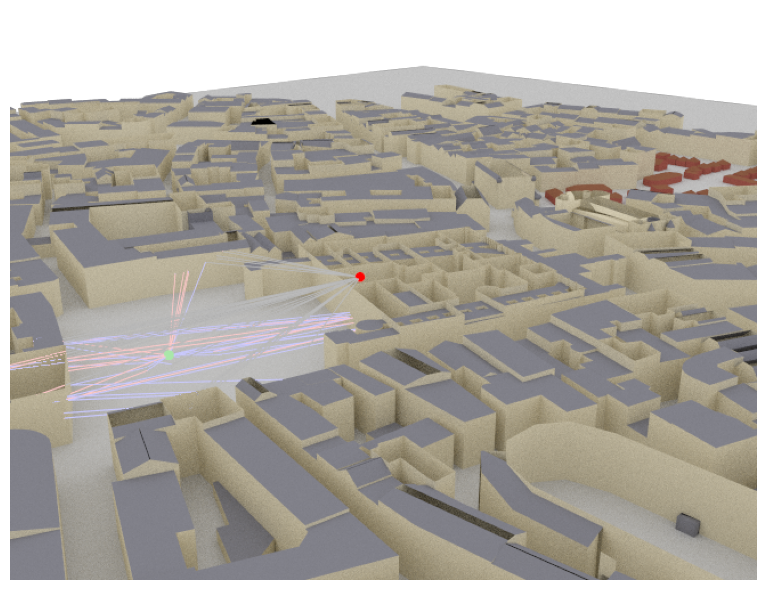

In [21]:
if no_preview:
    scene.render(camera=my_cam, paths=paths, clip_at=20);
else:
    scene.preview(paths=paths, clip_at=20);

In [22]:
a, tau = paths.cir(normalize_delays=True, out_type="numpy")

print("Shape of a: ", a.shape)

print("Shape of tau: ", tau.shape)

Shape of a:  (1, 2, 1, 1, 27, 1)
Shape of tau:  (1, 2, 1, 1, 27)


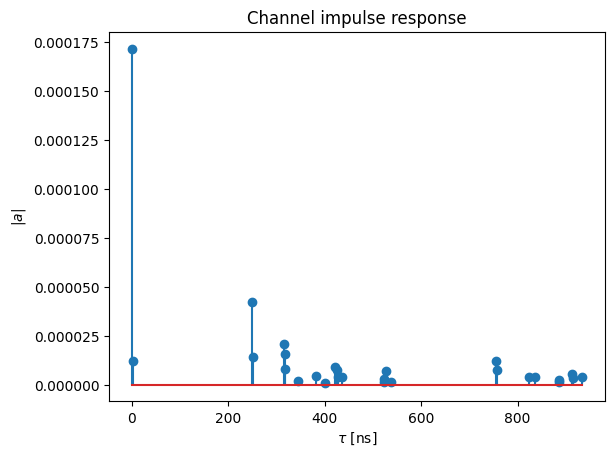

In [23]:
t = tau[0,0,0,0,:]/1e-9 # Scale to ns
a_abs = np.abs(a)[0,0,0,0,:,0]
a_max = np.max(a_abs)

plt.figure()
plt.title("Channel impulse response")
plt.stem(t, a_abs)
plt.xlabel(r"$\tau$ [ns]")
plt.ylabel(r"$|a|$");

Shape of h_freq:  (1, 2, 1, 1, 1, 1024)


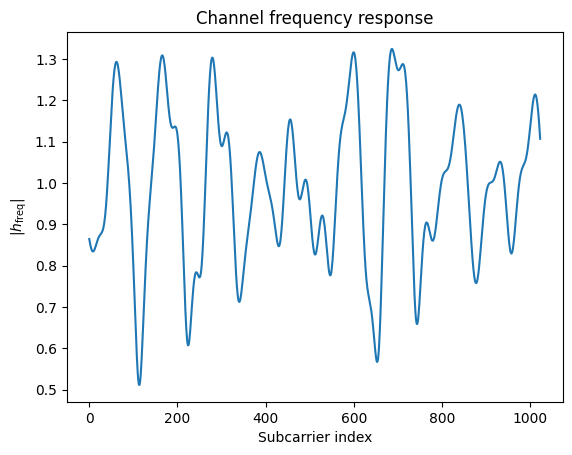

In [24]:
num_subcarriers = 1024
subcarrier_spacing=30e3

frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)

h_freq = paths.cfr(frequencies=frequencies,
                   normalize=True, # Normalize energy
                   normalize_delays=True,
                   out_type="numpy")

print("Shape of h_freq: ", h_freq.shape)

plt.figure()
plt.plot(np.abs(h_freq)[0,0,0,0,0,:]);
plt.xlabel("Subcarrier index");
plt.ylabel(r"|$h_\text{freq}$|");
plt.title("Channel frequency response");

Shape of taps:  (1, 2, 1, 1, 1, 107)


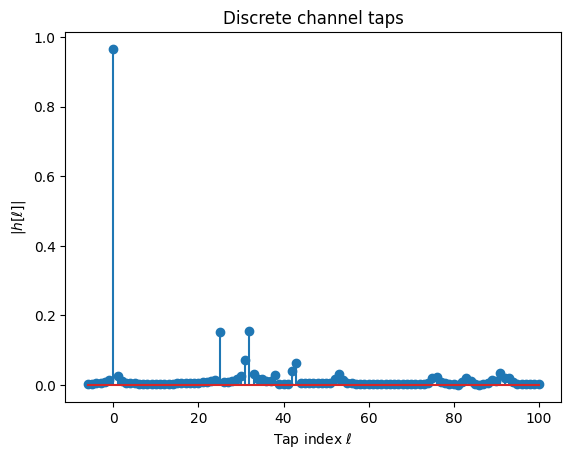

In [25]:
taps = paths.taps(bandwidth=100e6,
                  l_min=-6,
                  l_max=100,
                  sampling_frequency=None,
                  normalize=True,
                  normalize_delays=True,
                  out_type="numpy")
print("Shape of taps: ", taps.shape)

plt.figure()
plt.stem(np.arange(-6, 101), np.abs(taps)[0,0,0,0,0]);
plt.xlabel(r"Tap index $\ell$");
plt.ylabel(r"|$h[\ell]|$");
plt.title("Discrete channel taps");

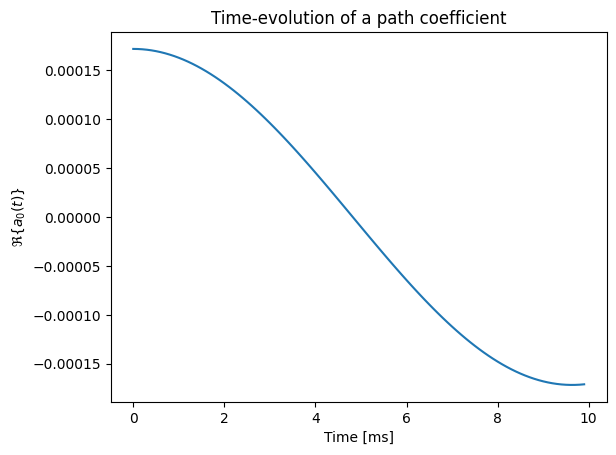

In [26]:
scene.get("tx").velocity = [10, 0, 0]

paths_mob = p_solver(scene=scene,
                     max_depth=5,
                     los=True,
                     specular_reflection=True,
                     diffuse_reflection=False,
                     refraction=True,
                     synthetic_array=True,
                     seed=41)

num_time_steps=100
sampling_frequency = 1e4
a_mob, _ = paths_mob.cir(sampling_frequency=sampling_frequency,
                         num_time_steps=num_time_steps,
                         out_type="numpy")

plt.figure()
plt.plot(np.arange(num_time_steps)/sampling_frequency*1000,
         a_mob[0,0,0,0,0].real);
plt.xlabel("Time [ms]");
plt.ylabel(r"$\Re\{a_0(t) \}$");
plt.title("Time-evolution of a path coefficient");

In [27]:
rm_solver = RadioMapSolver()

rm = rm_solver(scene=scene,
               max_depth=5,
               cell_size=[1,1],
               samples_per_tx=10**6)

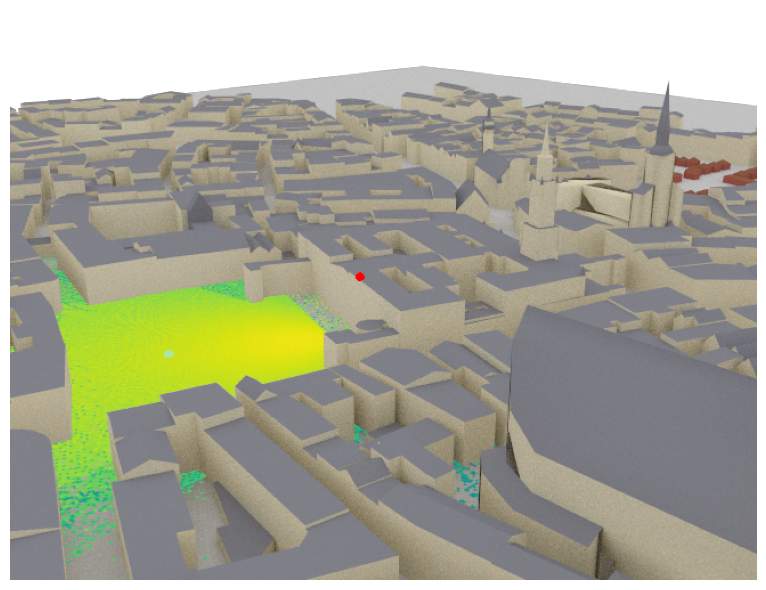

In [28]:
if no_preview:
    scene.render(camera=my_cam, radio_map=rm);
else:
    scene.preview(radio_map=rm);